# Temporal Mamba Sensitivity And Ablation Studies

This notebook runs repeated `tgbn-trade` experiments around the tuned Temporal Mamba sheaf baseline, then aggregates mean and standard deviation across 5 seeds.

It covers:
- Sensitivity analysis over major hyperparameters.
- Ablation studies over architecture flags that turn model components on or off.
- Error-bar plots for the sensitivity sweeps.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'exp').exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'exp').exists(), 'Run this notebook from the repo root or notebooks/.'

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from exp.temporal_mamba_studies import (
    build_ablation_experiments,
    build_sensitivity_experiments,
    make_trade_baseline_config,
    plot_sensitivity_results,
    prepare_temporal_experiment_context,
    run_experiments,
    summarize_experiments,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)


/home/zhuowez1/miniconda3/envs/nsd/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
DATASET_NAME = 'tgbn-trade'
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
BASE_SEED = 43
REPEATS = 3
# The study design changed from the earlier cached 3-point sweeps.
# Keep this True for the next run so the raw CSVs are regenerated.
FORCE_RERUN = True

# Keep training affordable, but evaluate on the full official TGB
# validation/test splits using the standard evaluator.
SPLIT_CAPS = {
    'train': 2048,
    'val': None,
    'test': None,
}

BASE_CONFIG = make_trade_baseline_config()


def _unique_ints(values, min_value=1):
    cleaned = []
    for value in values:
        value = max(min_value, int(value))
        if value not in cleaned:
            cleaned.append(value)
    return cleaned


# Use denser 5-point sweeps around the tuned configuration.
# We intentionally skip lr, weight_decay, dropout, and closure_hops.
SENSITIVITY_GRID = {
    'time_window': _unique_ints([1, 2, BASE_CONFIG['time_window'], 4, 5], min_value=1),
    'hidden_channels': _unique_ints([16, 32, BASE_CONFIG['hidden_channels'], 96, 128], min_value=8),
    'layers': _unique_ints([2, 3, 4, 5, 6], min_value=2),
    'd': _unique_ints([2, 3, BASE_CONFIG['d'], 5, 6], min_value=2),
    'temporal_d_model': _unique_ints([8, 16, BASE_CONFIG['temporal_d_model'], 48, 64], min_value=8),
    'temporal_bptt_steps': _unique_ints([2, 4, BASE_CONFIG['temporal_bptt_steps'], 16, 32], min_value=1),
}

ABLATION_FLAGS = [
    'left_weights',
    'right_weights',
    'second_linear',
    'edge_weights',
]

ARTIFACT_DIR = REPO_ROOT / 'notebooks' / 'artifacts' / 'temporal-mamba-trade-studies'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

SENSITIVITY_RAW_PATH = ARTIFACT_DIR / 'sensitivity_raw.csv'
SENSITIVITY_SUMMARY_PATH = ARTIFACT_DIR / 'sensitivity_summary.csv'
SENSITIVITY_FIG_PATH = ARTIFACT_DIR / 'sensitivity_error_bars.png'
ABLATION_RAW_PATH = ARTIFACT_DIR / 'ablation_raw.csv'
ABLATION_SUMMARY_PATH = ARTIFACT_DIR / 'ablation_summary.csv'

display(Markdown('**Baseline configuration (exact best-trial reference)**'))
display(pd.DataFrame([BASE_CONFIG]).T.rename(columns={0: 'value'}))
print({
    'dataset': DATASET_NAME,
    'device': str(DEVICE),
    'repeats': REPEATS,
    'artifact_dir': str(ARTIFACT_DIR),
    'split_caps': SPLIT_CAPS,
    'evaluation': 'Full official TGB validation/test splits with the standard evaluator',
    'sensitivity_parameters': list(SENSITIVITY_GRID.keys()),
    'choices_per_parameter': {key: len(values) for key, values in SENSITIVITY_GRID.items()},
    'baseline_centering': 'Each sensitivity sweep includes the exact tuned value from temporal_mamba_hyperparameter_tuning.ipynb',
})


**Baseline configuration (exact best-trial reference)**

,value
time_window,3
lr,0.012488
weight_decay,0.0
hidden_channels,64
layers,3
dropout,0.0
d,4
temporal_d_model,32
stateful_temporal,True
closure_hops,2


{'dataset': 'tgbn-trade', 'device': 'cuda:0', 'repeats': 3, 'artifact_dir': '/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies', 'split_caps': {'train': 2048, 'val': None, 'test': None}, 'evaluation': 'Full official TGB validation/test splits with the standard evaluator', 'sensitivity_parameters': ['time_window', 'hidden_channels', 'layers', 'd', 'temporal_d_model', 'temporal_bptt_steps'], 'choices_per_parameter': {'time_window': 5, 'hidden_channels': 5, 'layers': 5, 'd': 5, 'temporal_d_model': 5, 'temporal_bptt_steps': 5}, 'baseline_centering': 'Each sensitivity sweep includes the exact tuned value from temporal_mamba_hyperparameter_tuning.ipynb'}


In [7]:
context = prepare_temporal_experiment_context(
    DATASET_NAME,
    SPLIT_CAPS,
    device=DEVICE,
    seed=BASE_SEED,
    preload_time_windows=SENSITIVITY_GRID['time_window'],
)

display(Markdown('**Snapshot summary for cached time windows**'))
display(context.snapshot_table())
print({
    'metric_name': context.metric_name,
    'split_source': context.split_source,
    'num_nodes': context.num_nodes,
    'output_dim': context.output_dim,
    'train_cap': context.split_caps['train'],
    'val_cap': context.split_caps['val'],
    'test_cap': context.split_caps['test'],
})


**Snapshot summary for cached time windows**

,time_window,window_label,train_edges,train_snapshots,train_mean_edges,train_labelled_snapshots,val_edges,val_snapshots,val_labelled_snapshots,test_edges,test_snapshots,test_labelled_snapshots
0,1,1,16384,2,8192.0,1,73170,4,4,57851,3,3
1,2,2,16384,1,16384.0,1,73170,2,2,57851,2,2
2,3,3,16384,1,16384.0,1,73170,2,2,57851,1,1
3,4,4,16384,1,16384.0,1,73170,1,1,57851,1,1
4,5,5,16384,1,16384.0,1,73170,1,1,57851,1,1


{'metric_name': 'ndcg', 'split_source': 'official_tgb_masks', 'num_nodes': 255, 'output_dim': 255, 'train_cap': 2048, 'val_cap': None, 'test_cap': None}


The default sensitivity study is intentionally compute-heavy: each selected hyperparameter now uses a 5-point sweep and each experiment is repeated `REPEATS = 3` times.

This notebook intentionally skips `lr`, `weight_decay`, `dropout`, and `closure_hops` in the sensitivity analysis. If you want a quicker pass first, trim `SENSITIVITY_GRID`, reduce `ABLATION_FLAGS`, or lower `REPEATS` before running the execution cells.

In [8]:
sensitivity_experiments = build_sensitivity_experiments(BASE_CONFIG, SENSITIVITY_GRID)
sensitivity_plan_df = pd.DataFrame([
    {
        'parameter': spec['parameter'],
        'value': spec['value_label'],
        'time_window': spec['config'].get('time_window'),
    }
    for spec in sensitivity_experiments
])

display(Markdown(f'**Sensitivity experiments:** `{len(sensitivity_experiments)}` configs x `{REPEATS}` repeats'))
display(sensitivity_plan_df)


**Sensitivity experiments:** `30` configs x `3` repeats

,parameter,value,time_window
0,time_window,3,3
1,time_window,1,1
2,time_window,2,2
3,time_window,4,4
4,time_window,5,5
5,hidden_channels,64,3
6,hidden_channels,16,3
7,hidden_channels,32,3
8,hidden_channels,96,3
9,hidden_channels,128,3


In [ ]:
if SENSITIVITY_RAW_PATH.exists() and not FORCE_RERUN:
    sensitivity_raw_df = pd.read_csv(SENSITIVITY_RAW_PATH)
else:
    sensitivity_raw_df = run_experiments(
        context,
        sensitivity_experiments,
        repeats=1,
        seed_base=BASE_SEED,
        progress=True,
    )
    sensitivity_raw_df.to_csv(SENSITIVITY_RAW_PATH, index=False)

sensitivity_summary_df = summarize_experiments(sensitivity_raw_df)
sensitivity_summary_df.to_csv(SENSITIVITY_SUMMARY_PATH, index=False)

sensitivity_display_cols = [
    'parameter',
    'value_label',
    'best_val_metric_mean',
    'best_val_metric_std',
    'best_test_metric_mean',
    'best_test_metric_std',
    'best_epoch_mean',
    'best_epoch_std',
]
display(sensitivity_summary_df[sensitivity_display_cols])


,parameter,value_label,best_val_metric_mean,best_val_metric_std,best_test_metric_mean,best_test_metric_std,best_epoch_mean,best_epoch_std
0,closure_hops,1.000000e+00,0.997688,0.000652,0.997688,0.000652,136.4,17.854971
1,closure_hops,2.000000e+00,0.997613,0.001545,0.997613,0.001545,130.8,19.929877
2,closure_hops,3.000000e+00,0.997801,0.000862,0.997801,0.000862,148.4,6.841053
3,d,2.000000e+00,0.997400,0.001388,0.997400,0.001388,167.2,26.023067
4,d,4.000000e+00,0.997728,0.000444,0.997728,0.000444,122.0,31.144823
5,d,6.000000e+00,0.997309,0.001093,0.997309,0.001093,134.4,31.855926
6,dropout,0.000000e+00,0.997541,0.000760,0.997541,0.000760,129.6,31.157664
7,dropout,5.000000e-02,0.988764,0.001787,0.988764,0.001787,127.2,17.753873
8,dropout,1.000000e-01,0.988394,0.001405,0.988394,0.001405,174.4,28.892906
9,hidden_channels,3.200000e+01,0.996500,0.001730,0.996500,0.001730,140.0,22.271057


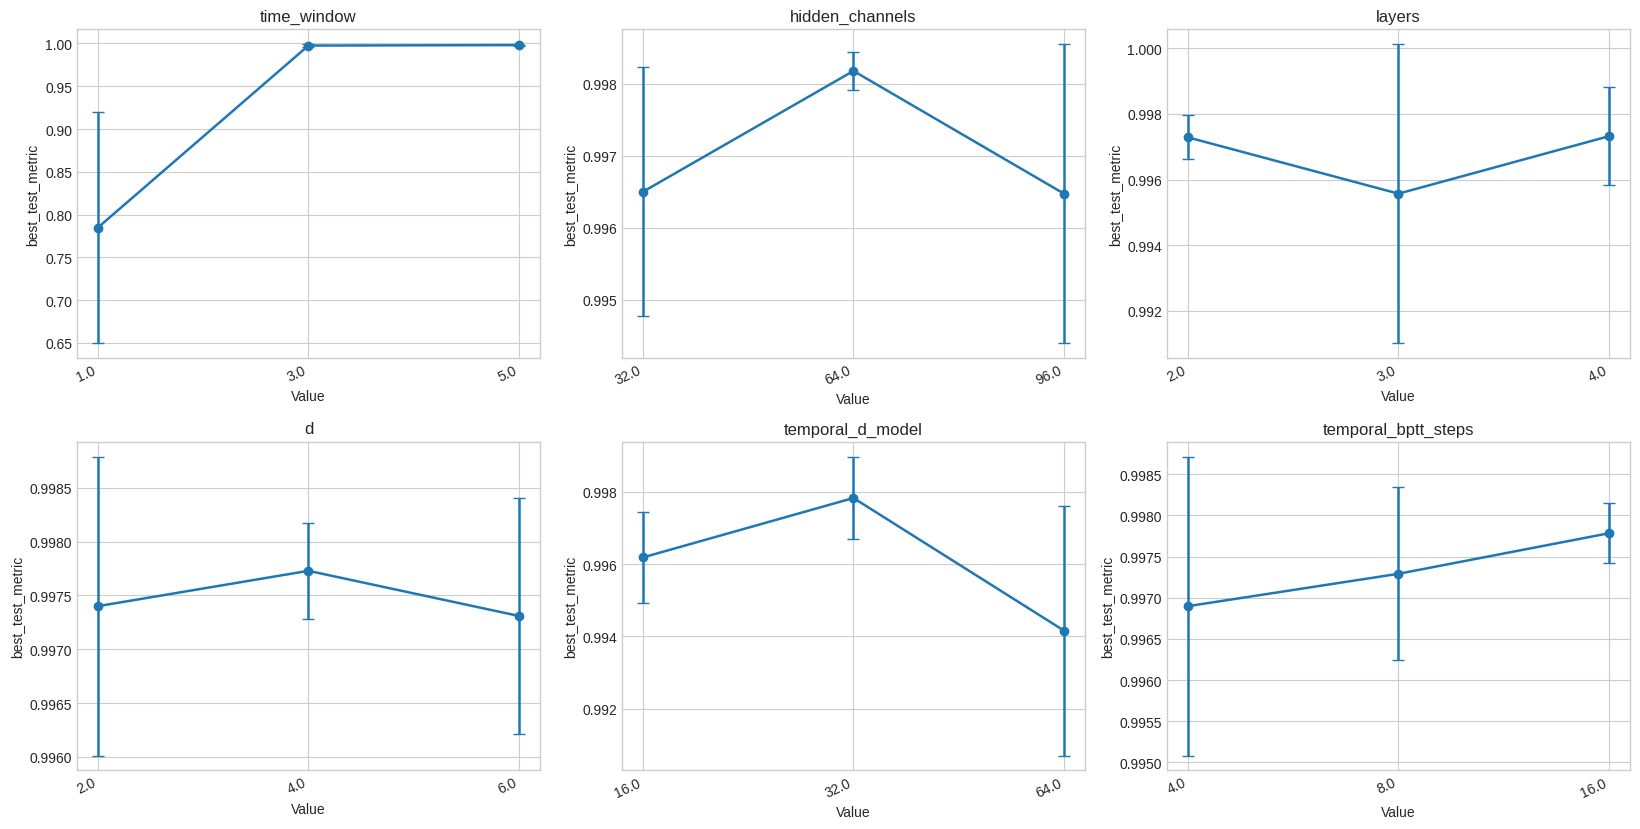

{'sensitivity_figure': '/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/sensitivity_error_bars.png'}


In [10]:
fig, axes = plot_sensitivity_results(
    sensitivity_summary_df,
    metric_col='best_test_metric_mean',
    error_col='best_test_metric_std',
    parameter_order=list(SENSITIVITY_GRID.keys()),
)
fig.savefig(SENSITIVITY_FIG_PATH, dpi=200, bbox_inches='tight')
plt.show()
print({'sensitivity_figure': str(SENSITIVITY_FIG_PATH)})


In [5]:
ablation_experiments = build_ablation_experiments(BASE_CONFIG, ABLATION_FLAGS)
ablation_plan_df = pd.DataFrame([
    {
        'flag': spec['parameter'],
        'value': spec['value_label'],
    }
    for spec in ablation_experiments
])

display(Markdown(f'**Ablation experiments:** `{len(ablation_experiments)}` configs x `{REPEATS}` repeats'))
display(ablation_plan_df)


**Ablation experiments:** `8` configs x `3` repeats

,flag,value
0,left_weights,False
1,left_weights,True
2,right_weights,False
3,right_weights,True
4,second_linear,False
5,second_linear,True
6,edge_weights,False
7,edge_weights,True


In [ ]:
FORCE_RERUN = True

if ABLATION_RAW_PATH.exists() and not FORCE_RERUN:
    ablation_raw_df = pd.read_csv(ABLATION_RAW_PATH)
else:
    ablation_raw_df = run_experiments(
        context,
        ablation_experiments,
        repeats=REPEATS,
        seed_base=BASE_SEED,
        progress=True,
    )
    ablation_raw_df.to_csv(ABLATION_RAW_PATH, index=False)

ablation_summary_df = summarize_experiments(ablation_raw_df)
ablation_summary_df.to_csv(ABLATION_SUMMARY_PATH, index=False)

ablation_display_cols = [
    'parameter',
    'value_label',
    'best_val_metric_mean',
    'best_val_metric_std',
    'best_test_metric_mean',
    'best_test_metric_std',
    'best_epoch_mean',
]
display(ablation_summary_df[ablation_display_cols])

ablation_pivot = ablation_summary_df.pivot(index='parameter', columns='value_label', values='best_test_metric_mean')
display(Markdown('**Ablation mean test metric by flag value**'))
display(ablation_pivot)


Temporal Mamba study runs:  12%|█▎        | 3/24 [25:12<2:57:02, 505.82s/it]

In [ ]:
print({
    'sensitivity_raw': str(SENSITIVITY_RAW_PATH),
    'sensitivity_summary': str(SENSITIVITY_SUMMARY_PATH),
    'ablation_raw': str(ABLATION_RAW_PATH),
    'ablation_summary': str(ABLATION_SUMMARY_PATH),
    'sensitivity_figure': str(SENSITIVITY_FIG_PATH),
})


{'sensitivity_raw': '/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/sensitivity_raw.csv', 'sensitivity_summary': '/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/sensitivity_summary.csv', 'ablation_raw': '/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/ablation_raw.csv', 'ablation_summary': '/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/ablation_summary.csv', 'sensitivity_figure': '/home/zhuowez1/project/neural-sheaf-diffusion/notebooks/artifacts/temporal-mamba-trade-studies/sensitivity_error_bars.png'}
